# 05 — Cluster Profiles

This notebook analyses each cluster and builds a financial persona 
profile for each one. We look at the average values of every feature 
per cluster, the demographic breakdown, and translate the numbers into 
a named persona type with a written description.

**Input:** `../data/customers_clustered.csv`  
**Output:** The five financial persona types

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('../data/customers_clustered.csv')

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print("\nCustomers per cluster:")
print(data['cluster'].value_counts().sort_index())

Shape: (1219, 18)
Columns: ['client_id', 'gender', 'current_age', 'total_spend', 'avg_transaction', 'transaction_count', 'merchant_diversity', 'debt_to_income', 'credit_utilisation', 'income_vs_area', 'credit_score', 'yearly_income', 'total_debt', 'total_credit_limit', 'num_cards', 'has_dark_web_card', 'years_to_retirement', 'cluster']

Customers per cluster:
cluster
0    263
1    495
2    371
3     64
4     26
Name: count, dtype: int64


In [2]:
# Calculate the mean of each feature per cluster
# This gives us the "typical customer" in each group
# We exclude non-numeric and identifier columns

profile_cols = [
    'current_age',
    'years_to_retirement', 
    'yearly_income',
    'total_debt',
    'credit_score',
    'total_credit_limit',
    'num_cards',
    'total_spend',
    'avg_transaction',
    'transaction_count',
    'merchant_diversity',
    'debt_to_income'
]

profiles = data.groupby('cluster')[profile_cols].mean().round(2)

# Also add cluster size and gender breakdown
profiles['cluster_size'] = data['cluster'].value_counts().sort_index()
profiles['pct_female'] = data.groupby('cluster')['gender'].apply(
    lambda x: (x == 'Female').sum() / len(x) * 100
).round(1)

print(profiles.T)

cluster                      0          1          2          3          4
current_age              74.21      44.86      48.67      54.00      55.04
years_to_retirement      -8.35      21.80      17.88      13.89       9.69
yearly_income         37978.44   38006.26   60969.60   45517.38   25558.35
total_debt            14024.25   65323.84   91211.51      27.98   41424.54
credit_score            714.04     710.34     712.53     741.98     698.73
total_credit_limit    65433.09   35085.86   74543.30   59348.23     334.15
num_cards                 4.78       3.11       3.79       4.09       2.00
total_spend          482651.48  293738.33  719691.40  460303.69  116644.81
avg_transaction          42.58      37.35      55.46      43.75      17.80
transaction_count     11530.21    8410.12   14088.84   10909.45    7126.88
merchant_diversity       79.49      73.83      82.82      77.11      40.42
debt_to_income            0.40       1.70       1.54       0.00       1.36
cluster_size            2

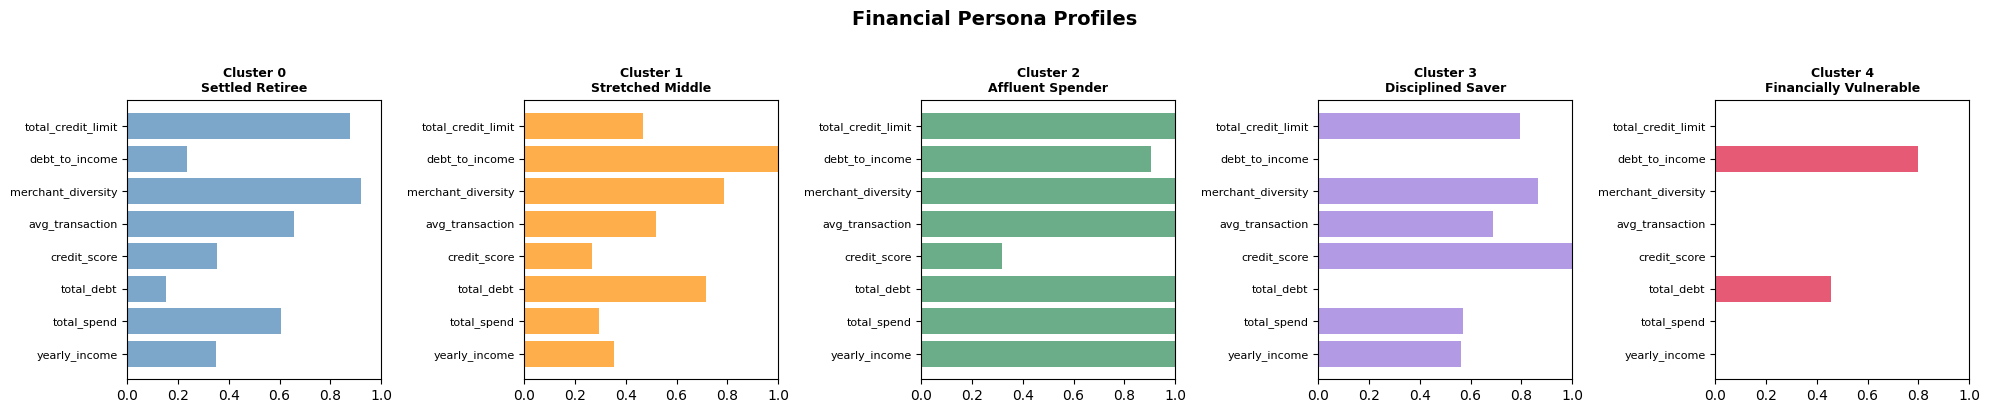

Chart saved


In [3]:
# Radar chart showing each cluster's profile
# We normalise each feature to 0-1 scale just for visualisation purposes

from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np

# Select key features for the radar
radar_cols = [
    'yearly_income', 'total_spend', 'total_debt',
    'credit_score', 'avg_transaction', 'merchant_diversity',
    'debt_to_income', 'total_credit_limit'
]

# Normalise to 0-1 for comparison
radar_data = profiles[radar_cols].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

# Persona names
persona_names = {
    0: 'Settled Retiree',
    1: 'Stretched Middle',
    2: 'Affluent Spender',
    3: 'Disciplined Saver',
    4: 'Financially Vulnerable'
}

# Plot
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson']

for i, (cluster, ax) in enumerate(zip(range(5), axes)):
    vals = radar_norm.loc[cluster].values
    bars = ax.barh(radar_cols, vals, color=colors[i], alpha=0.7)
    ax.set_xlim(0, 1)
    ax.set_title(f"Cluster {cluster}\n{persona_names[cluster]}", 
                 fontweight='bold', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Financial Persona Profiles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")